In [1]:
#!/usr/bin/env python3
# make_tornado_from_ulmm_pickles.py
"""
Tornado sensitivity plot using existing ULMM pickles (NYC) — FAST screening version.

What’s new (speedups):
- FAST toggle for preliminary sensitivity: baseline H1 (DEB) computed once; scenarios reuse it.
- Reuse external cached segment-event counts if present (cache_nyc_ulmm/counts_311.pkl, counts_truck.pkl).
- ServC: demand subsampling + Dijkstra cutoff + incremental coverage AUC (no repeated Dijkstras per q).
- H3: nearest-access exposure via one super-source Dijkstra (not per-demand).
- Δτ_d computed via multi-source (super-source) runs for baseline/post shock.
- RPE: smaller demand sample and capped K in FAST mode.
- Fewer random draws for the benchmark in FAST mode.

Outputs: figs/fig-params-tornado.png
"""

import os
import math
import pickle
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, Tuple, Optional, Iterable, List

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
from shapely.geometry import Point
import matplotlib.pyplot as plt
import requests

# --------------------
# CONFIG
# --------------------
PICKLES_DIR = Path("ulmm_pickles")
OUT_DIR = Path("figs"); OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE = Path("cache_tornado"); CACHE.mkdir(parents=True, exist_ok=True)
EXT_CACHE_DIR = Path("cache_nyc_ulmm")  # optional: reuse counts from external pipeline if present

VEHICLE = "van"  # "van" or "cargo_bike"
CITY_MATCH = "new-york-city"  # only NYC has held-out curb activity in this script

# Baseline params (can tweak here)
BASELINE = {
    "lambda": 0.5,      # curb salience on streets
    "kappa_delta": 1.0, # κ = delta * median(c_base)
    "gamma": 0.0,       # DEB damping (0 by default)
    "K": 25,            # #paths for RPE (global K-shortest to virtual sink)
    "eta": 1.0,         # Gibbs temperature for RPE
    "p_shock": 0.015,   # shock budget
}

# One-at-a-time scenarios around baseline
USE_WIDE_SCENARIOS = True  # set False to keep the milder set
SCENARIOS = (
    [
        ("λ ↓", {"lambda": 0.25}),
        ("λ ↑", {"lambda": 0.75}),
        ("κ ↓", {"kappa_delta": 0.5}),
        ("κ ↑", {"kappa_delta": 2.0}),
        ("γ = 2", {"gamma": 2.0}),
        ("K = 10", {"K": 10}),
        ("K = 50", {"K": 50}),
        ("η = 0.5", {"eta": 0.5}),
        ("η = 2.0", {"eta": 2.0}),
    ]
    if not USE_WIDE_SCENARIOS else
    [
        ("λ = 0",   {"lambda": 0.0}),
        ("λ = 1",   {"lambda": 1.0}),
        ("κ = 0",   {"kappa_delta": 0.0}),
        ("κ = 3",   {"kappa_delta": 3.0}),
        ("γ = 2",   {"gamma": 2.0}),
        ("K = 10",  {"K": 10}),
        ("K = 75",  {"K": 75}),
        ("η = 0.5", {"eta": 0.5}),
        ("η = 2.0", {"eta": 2.0}),
        ("p = 3%",  {"p_shock": 0.03}),
    ]
)

# Mapping tolerances / constants
EVENT_TO_EDGE_MAXDIST_M = 30.0
ACCESS_ACTIVITY_RADIUS_M = 50.0
BUSINESS_HOURS = (9, 17)
RNG = np.random.default_rng(12345)

# -------- Speed knobs for tornado screening --------
FAST = True                      # baseline exact; scenarios cheap
SERVC_DEMAND_SAMPLE = 3000       # a bit more demand to help κ show up
SERVC_TAU_MAX = 600.0            # seconds; cutoff for Dijkstra in ServC and coverage
RPE_SAMPLE_N_FAST = 600          # larger sample so High-RPE tertile actually changes
K_FAST = 50                      # allow more path diversity in FAST
RANDOM_BENCH_DRAWS = 8           # a few more draws for stability

# Globals hoisted once (populated in main)
_EDGES_MID: Optional[gpd.GeoDataFrame] = None
_C311: Optional[pd.Series] = None
_CTRK: Optional[pd.Series] = None

# --------------------
# Utils
# --------------------
def load_ulmm_nyc() -> dict:
    """Load the NYC ULMM pickle."""
    pkls = sorted(PICKLES_DIR.glob("ulmm_*nyc*.pkl")) + sorted(PICKLES_DIR.glob("ulmm_*new-york-city*.pkl"))
    if not pkls:
        raise FileNotFoundError("NYC ULMM pickle not found in ulmm_pickles/.")
    with open(pkls[0], "rb") as f:
        ulmm = pickle.load(f)
    return ulmm

def try_load_cached_counts():
    """Try to reuse counts produced by the cached NYC pipeline (if any)."""
    if not EXT_CACHE_DIR.exists():
        return None, None
    c311_path = EXT_CACHE_DIR / "counts_311.pkl"
    ctrk_path = EXT_CACHE_DIR / "counts_truck.pkl"
    try:
        c_311 = pickle.load(open(c311_path, "rb")) if c311_path.exists() else None
        c_trk = pickle.load(open(ctrk_path, "rb")) if ctrk_path.exists() else None
        # Ensure Series with MultiIndex (u,v,key)
        for s in (c_311, c_trk):
            if s is not None and not isinstance(s.index, pd.MultiIndex):
                s.index = pd.MultiIndex.from_tuples(s.index, names=["u","v","key"])
        return c_311, c_trk
    except Exception:
        return None, None

def set_edge_weight(G: nx.MultiDiGraph, veh: str, lam: float, gamma: float = 0.0) -> None:
    """
    Create/overwrite an edge weight 'tt' = c_base * (1 + lam * phi_veh).
    Optionally apply damping for DEB-style scoring (exponential on a 'viability' friction
    that excludes lane scarcity to avoid double-penalizing speed).
    """
    for _, _, _, d in G.edges(keys=True, data=True):
        c0 = float(d.get("c_base", np.nan))
        phi = float(d.get(f"phi_{veh}", 0.0))
        if not np.isfinite(c0):
            c0 = float(d.get("length", 0.0)) / (max(float(d.get("speed_kph", 30.0)), 1.0) * 1000.0 / 3600.0)
        d["tt"] = c0 * (1.0 + lam * phi)
        if gamma and gamma > 0.0:
            phi_viab = max(
                0.0,
                float(d.get("f_restricted_access", d.get("f_restricted", 0.0)))
                + float(d.get("f_bus_only", 0.0))
                + float(d.get("f_pedestrian_zone", 0.0))
                + float(d.get("f_slope", 0.0))
                + float(d.get("f_no_stopping", 0.0)),
            )
            d["deb_damp"] = math.exp(-gamma * float(phi_viab))
        else:
            d["deb_damp"] = 1.0

def top_decile_lift(score: pd.Series, label: pd.Series) -> float:
    n = len(score)
    if n == 0:
        return float("nan")
    k = max(1, int(math.ceil(0.10 * n)))
    idx = score.sort_values(ascending=False).index[:k]
    top_pos_rate = label.loc[idx].mean()
    base_rate = label.mean()
    return (top_pos_rate / base_rate) if base_rate > 0 else float("inf")

def zscore(x: pd.Series) -> pd.Series:
    mu, sd = x.mean(), x.std(ddof=0)
    if sd <= 0 or not np.isfinite(sd):
        sd = 1.0
    return (x - mu) / sd

def to_3857(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        gdf = gdf.set_crs(4326)
    return gdf.to_crs(3857)

def edges_midpoints_gdf(G: nx.MultiDiGraph) -> gpd.GeoDataFrame:
    rows = []
    for u, v, k, d in G.edges(keys=True, data=True):
        geom = d.get("geometry")
        if geom is None:
            rows.append({"u": u, "v": v, "key": k, "geometry": None})
        else:
            try:
                mid = geom.interpolate(0.5, normalized=True)
            except Exception:
                mid = None
            rows.append({"u": u, "v": v, "key": k, "geometry": mid})
    gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=4326)
    gdf = to_3857(gdf)
    gdf["length_m"] = gdf.geometry.length.values if gdf.geometry.notna().any() else 0.0
    return gdf

def sjoin_nearest_points_to_edges(points_3857: gpd.GeoDataFrame, edges_mid_3857: gpd.GeoDataFrame, max_m: float) -> pd.Series:
    if points_3857.empty:
        return pd.Series(dtype=int)
    joined = gpd.sjoin_nearest(points_3857, edges_mid_3857[["u","v","key","geometry"]], how="left", distance_col="dist")
    joined = joined[joined["dist"] <= max_m]
    return joined.groupby(["u","v","key"]).size()

def node_incident_phi_mean(G: nx.MultiDiGraph, node: int, veh: str) -> float:
    vals = []
    for _, _, _, d in G.out_edges(node, keys=True, data=True):
        vals.append(float(d.get(f"phi_{veh}", 0.0)))
    for _, _, _, d in G.in_edges(node, keys=True, data=True):
        vals.append(float(d.get(f"phi_{veh}", 0.0)))
    return float(np.mean(vals)) if vals else 0.0

def single_source_lengths(G: nx.MultiDiGraph, source: int, weight_key="tt") -> Dict[int, float]:
    return nx.single_source_dijkstra_path_length(G, source, weight=weight_key)

# --------------------
# H1: Held-out outcomes (NYC only)
# --------------------
def fetch_311_illegal_parking(date_from: str, date_to: str) -> gpd.GeoDataFrame:
    cache = CACHE / f"nyc_311_{date_from}_{date_to}.pkl"
    if cache.exists():
        return pickle.load(open(cache, "rb"))

    url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"
    where = (
        f"created_date between '{date_from}T00:00:00.000' and '{date_to}T23:59:59.999' "
        f"AND complaint_type='Illegal Parking' AND latitude IS NOT NULL AND longitude IS NOT NULL"
    )
    params = {"$select": "created_date, latitude, longitude", "$where": where, "$limit": 50000, "$offset": 0}
    out = []
    offset = 0
    while True:
        params["$offset"] = offset
        r = requests.get(url, params=params, timeout=120)
        r.raise_for_status()
        rows = r.json()
        if not rows:
            break
        out.extend(rows)
        if len(rows) < 50000:
            break
        offset += 50000
    df = pd.DataFrame(out)
    if df.empty:
        gdf = gpd.GeoDataFrame(geometry=[], crs=4326).to_crs(3857)
        pickle.dump(gdf, open(cache, "wb")); return gdf
    df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
    df = df.dropna(subset=["created_date","latitude","longitude"])
    df = df[(df["created_date"].dt.weekday < 5) & (df["created_date"].dt.hour >= BUSINESS_HOURS[0]) & (df["created_date"].dt.hour < BUSINESS_HOURS[1])]
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude.astype(float), df.latitude.astype(float)), crs=4326).to_crs(3857)
    pickle.dump(gdf, open(cache, "wb"))
    return gdf

def fetch_truck_crashes(date_from: str, date_to: str) -> gpd.GeoDataFrame:
    cache = CACHE / f"nyc_truck_crash_{date_from}_{date_to}.pkl"
    if cache.exists():
        return pickle.load(open(cache, "rb"))

    url = "https://data.cityofnewyork.us/resource/h9gi-nx95.json"
    base_where = f"latitude IS NOT NULL AND longitude IS NOT NULL AND crash_date between '{date_from}T00:00:00.000' and '{date_to}T23:59:59.999'"
    params = {"$where": base_where, "$limit": 50000, "$offset": 0}
    out = []
    offset = 0
    while True:
        params["$offset"] = offset
        r = requests.get(url, params=params, timeout=120)
        r.raise_for_status()
        rows = r.json()
        if not rows:
            break
        out.extend(rows)
        if len(rows) < 50000:
            break
        offset += 50000
    df = pd.DataFrame(out)
    if df.empty:
        gdf = gpd.GeoDataFrame(geometry=[], crs=4326).to_crs(3857)
        pickle.dump(gdf, open(cache, "wb")); return gdf

    veh_cols = [c for c in df.columns if c.lower().startswith("vehicle_type_code")]
    if veh_cols:
        pat = r"(TRUCK|TRACTOR|COMMERCIAL)"
        mask = df[veh_cols].apply(lambda col: col.astype(str).str.upper().str.contains(pat, regex=True, na=False))
        df = df[mask.any(axis=1)]
    else:
        df = df.iloc[0:0]
    if df.empty:
        gdf = gpd.GeoDataFrame(geometry=[], crs=4326).to_crs(3857)
        pickle.dump(gdf, open(cache, "wb")); return gdf

    if "crash_time" in df.columns:
        ts = pd.to_datetime(df["crash_date"].astype(str) + " " + df["crash_time"].astype(str), errors="coerce")
    else:
        ts = pd.to_datetime(df["crash_date"], errors="coerce")
    df = df.assign(dt=ts).dropna(subset=["dt","latitude","longitude"])
    df = df[(df["dt"].dt.weekday < 5) & (df["dt"].dt.hour >= BUSINESS_HOURS[0]) & (df["dt"].dt.hour < BUSINESS_HOURS[1])]
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude.astype(float), df.latitude.astype(float)), crs=4326).to_crs(3857)
    pickle.dump(gdf, open(cache, "wb"))
    return gdf

# --------------------
# DEB (Brandes subset)
# --------------------
def deb_edge_brandes_subset(G: nx.MultiDiGraph,
                            sources: Iterable[int],
                            source_w: Dict[int, float],
                            target_w: Dict[int, float],
                            weight_key: str = "tt",
                            edge_damp_key: Optional[str] = "deb_damp") -> Dict[Tuple[int,int,int], float]:
    """
    Weighted, directed Brandes dependency accumulation with pair weights and optional edge damping.
    """
    e_c = defaultdict(float)
    tol = 1e-9
    import heapq

    for s in sources:
        S = []
        P = defaultdict(list)
        sigma = defaultdict(float)
        dist = defaultdict(lambda: math.inf)

        sigma[s] = 1.0
        dist[s] = 0.0
        Q = [(0.0, s)]

        while Q:
            dv, v = heapq.heappop(Q)
            if dv > dist[v] + 1e-12:
                continue
            S.append(v)
            for w in G.successors(v):
                # min over parallel edges
                min_w = math.inf
                for k, data in G[v][w].items():
                    wtt = float(data.get(weight_key, 1.0))
                    if wtt < min_w:
                        min_w = wtt
                vw = dist[v] + min_w
                if vw < dist[w] - tol:
                    dist[w] = vw
                    heapq.heappush(Q, (vw, w))
                    sigma[w] = sigma[v]
                    P[w] = [v]
                elif abs(vw - dist[w]) <= tol:
                    sigma[w] += sigma[v]
                    P[w].append(v)

        delta = defaultdict(float)
        sw = float(source_w.get(s, 1.0))
        while S:
            w = S.pop()
            coef = float(target_w.get(w, 0.0))
            for v in P.get(w, []):
                if sigma[w] == 0:
                    continue
                contrib = (sigma[v] / max(sigma[w], 1e-9)) * (coef + delta[w])

                # split across step-consistent parallel edges
                candidates = []
                if v in G and w in G[v]:
                    for k, data in G[v][w].items():
                        wtt = float(data.get(weight_key, 1.0))
                        if abs(dist[v] + wtt - dist[w]) <= tol:
                            candidates.append((v,w,k))
                m = max(1, len(candidates))
                for edge in candidates:
                    damp = 1.0
                    if edge_damp_key:
                        try:
                            damp_vals = [float(d_.get(edge_damp_key, 1.0)) for _, d_ in G[edge[0]][edge[1]].items()]
                            if damp_vals:
                                damp = float(np.mean(damp_vals))
                        except Exception:
                            damp = 1.0
                    e_c[edge] += sw * contrib * damp / m
                delta[v] += contrib
    return e_c

# --------------------
# ServC + coverage (FAST)
# --------------------
def compute_servc(G: nx.MultiDiGraph,
                  access_nodes: Dict[str,int],
                  demand_nodes: Dict[str,int],
                  w_d: Dict[str,float],
                  veh: str,
                  kappa_seconds: float,
                  orientation: str) -> pd.DataFrame:
    """
    FAST: optional demand subsample + Dijkstra cutoff.
    """
    # demand subsample (stable seed)
    d_items = list(demand_nodes.items())
    if FAST and len(d_items) > SERVC_DEMAND_SAMPLE:
        rng = np.random.default_rng(123)
        d_idx = rng.choice(len(d_items), size=SERVC_DEMAND_SAMPLE, replace=False)
        d_items = [d_items[i] for i in d_idx]

    rows = []
    if orientation.upper() == "AD":
        for a_id, node in access_nodes.items():
            phi_prox = node_incident_phi_mean(G, node, veh)
            dist = nx.single_source_dijkstra_path_length(
                G, node, weight="tt", cutoff=(SERVC_TAU_MAX if FAST else None)
            )
            tot = 0.0
            for d_id, dn in d_items:
                t = float(dist.get(dn, np.inf))
                if np.isfinite(t):
                    tot += (float(w_d.get(d_id, 1.0)) / max(t + kappa_seconds*phi_prox, 1e-6))
            rows.append({"a_id": a_id, "servc": tot, "phi_prox": phi_prox})
    else:
        Gr = G.reverse(copy=False)
        for a_id, node in access_nodes.items():
            phi_prox = node_incident_phi_mean(G, node, veh)
            dist = nx.single_source_dijkstra_path_length(
                Gr, node, weight="tt", cutoff=(SERVC_TAU_MAX if FAST else None)
            )
            tot = 0.0
            for d_id, dn in d_items:
                t = float(dist.get(dn, np.inf))
                if np.isfinite(t):
                    tot += (float(w_d.get(d_id, 1.0)) / max(t + kappa_seconds*phi_prox, 1e-6))
            rows.append({"a_id": a_id, "servc": tot, "phi_prox": phi_prox})
    out = pd.DataFrame(rows)
    out["ServC_z"] = zscore(out["servc"])
    return out

def cov_auc_delta_for_servc(G: nx.MultiDiGraph,
                            access_df: pd.DataFrame,
                            demand_df: pd.DataFrame,
                            veh: str,
                            kappa_seconds: float) -> float:
    """
    Compute ΔAUC (ServC vs median-quantile control) averaged over τ* ∈ {300, 600}s and orientations.
    FAST: precompute distances for all access once per τ*, incremental min over q, demand subsample.
    """
    if access_df.empty or demand_df.empty:
        return 0.0

    access_nodes = dict(zip(access_df["a_id"], access_df["i_node"]))
    demand_nodes = dict(zip(demand_df["d_id"], demand_df["i_node"]))
    w_d = dict(zip(demand_df["d_id"], demand_df["w"]))

    taus = [300, 600]

    # demand subsample aligned with compute_servc
    d_ids_all = list(demand_nodes.keys())
    if FAST and len(d_ids_all) > SERVC_DEMAND_SAMPLE:
        rng = np.random.default_rng(123)
        d_ids = list(np.array(d_ids_all)[rng.choice(len(d_ids_all), size=SERVC_DEMAND_SAMPLE, replace=False)])
    else:
        d_ids = d_ids_all

    def cov_curve(scores: pd.Series, orientation: str, tau_star: float) -> float:
        acc_sorted = scores.sort_values(ascending=False).index.tolist()
        # Precompute one length dict per access (with cutoff=tau_star)
        if orientation.upper() == "AD":
            lens = [nx.single_source_dijkstra_path_length(G, access_nodes[a], weight="tt", cutoff=tau_star)
                    for a in acc_sorted]
        else:
            Gr = G.reverse(copy=False)
            lens = [nx.single_source_dijkstra_path_length(Gr, access_nodes[a], weight="tt", cutoff=tau_star)
                    for a in acc_sorted]

        # Incremental min over growing top-k
        qs = np.linspace(0.05, 1.0, 20)
        cov = []
        current_min = {d: np.inf for d in d_ids}
        total_w = sum(w_d[d] for d in d_ids)
        k_prev = 0
        for q in qs:
            k = max(1, int(math.ceil(q * len(acc_sorted))))
            for i in range(k_prev, k):
                L = lens[i]
                for d in d_ids:
                    t = L.get(demand_nodes[d], np.inf)
                    if t < current_min[d]:
                        current_min[d] = t
            covered = sum(w_d[d] for d in d_ids if np.isfinite(current_min[d]) and current_min[d] <= tau_star)
            cov.append(covered / max(total_w, 1e-9))
            k_prev = k
        return np.trapz(np.array(cov), x=qs)

    # Build ServC for each orientation
    servc_ad = compute_servc(G, access_nodes, demand_nodes, w_d, veh, kappa_seconds, "AD")
    servc_da = compute_servc(G, access_nodes, demand_nodes, w_d, veh, kappa_seconds, "DA")

    auc_diffs = []
    for tau_star in taus:
        for orientation, servc_df in [("AD", servc_ad), ("DA", servc_da)]:
            if servc_df.empty:
                continue
            # ServC ranking
            auc_s = cov_curve(servc_df.set_index("a_id")["servc"], orientation, tau_star)
            # Median-quantile control: pick indices closest to median score
            s = servc_df[["a_id","servc"]].set_index("a_id")["servc"]
            s_med = s.median()
            ctrl = (-(s - s_med).abs()).sort_values(ascending=False)
            auc_m = cov_curve(ctrl, orientation, tau_star)
            auc_diffs.append(auc_s - auc_m)
    return float(np.mean(auc_diffs)) if auc_diffs else 0.0

# --------------------
# H3: Targeted vs Random shocks + RPE tertiles (FAST)
# --------------------
def nearest_access_exposure(G: nx.MultiDiGraph,
                            demand_df: pd.DataFrame,
                            access_df: pd.DataFrame,
                            veh: str,
                            orientation: str) -> pd.Series:
    """
    NAE via a single super-source Dijkstra from all access nodes.
    Paths are oriented access->...->demand (for AD). We accumulate edge counts weighted by demand w_d.
    """
    if access_df.empty or demand_df.empty:
        return pd.Series(dtype=float)
    access_nodes = dict(zip(access_df["a_id"], access_df["i_node"]))
    demand_nodes = dict(zip(demand_df["d_id"], demand_df["i_node"]))
    w_d = dict(zip(demand_df["d_id"], demand_df["w"]))

    # Build orientation graph
    H = G if orientation.upper() == "AD" else G.reverse(copy=True)
    # Super-source
    sstar = object()
    H2 = H.copy()
    H2.add_node(sstar)
    for an in access_nodes.values():
        H2.add_edge(sstar, an, tt=0.0)

    dist, paths = nx.single_source_dijkstra(H2, sstar, weight="tt")

    score = Counter()
    for d_id, dn in demand_nodes.items():
        pth = paths.get(dn)
        if not pth or len(pth) < 3:
            # no route from any access or only sstar->access without street edges
            continue
        # Skip the first hop (sstar -> access); accumulate street edges only
        for i in range(2, len(pth)):
            u, v = pth[i-1], pth[i]
            if G.has_edge(u, v):
                kk = min(G[u][v].items(), key=lambda kv: float(kv[1].get("tt", 1.0)))[0]
                score[(u, v, kk)] += float(w_d.get(d_id, 1.0))
            elif G.has_edge(v, u):  # fallback if direction flipped
                kk = min(G[v][u].items(), key=lambda kv: float(kv[1].get("tt", 1.0)))[0]
                score[(v, u, kk)] += float(w_d.get(d_id, 1.0))

    if not score:
        return pd.Series(dtype=float)
    s = pd.Series(score).sort_values(ascending=False)
    s.index = pd.MultiIndex.from_tuples(s.index, names=["u","v","key"])
    return s

def _min_time_to_any_access_all(G: nx.MultiDiGraph, access_nodes: Dict, orientation: str) -> Dict[int, float]:
    """
    Multi-source distances to all nodes via super-source; returns path_length dict.
    For AD: access->nodes on G; for DA: still from access, but on reversed graph.
    """
    if orientation.upper() == "AD":
        H = G
    else:
        H = G.reverse(copy=False)

    sstar = object()
    H2 = H.copy()
    H2.add_node(sstar)
    for an in access_nodes.values():
        H2.add_edge(sstar, an, tt=0.0)
    dist = nx.single_source_dijkstra_path_length(H2, sstar, weight="tt")
    return dist

def compute_delta_tau_percent(G: nx.MultiDiGraph,
                              demand_df: pd.DataFrame,
                              access_df: pd.DataFrame,
                              veh: str,
                              removed_edges: List[Tuple[int,int,int]],
                              orientation: str) -> Tuple[pd.Series, float]:
    """
    Return per-demand Δτ (%) where reachable, and conditional median (%).
    FAST: two multi-source (super-source) runs instead of many per-demand runs.
    """
    G2 = G.copy()
    for (u,v,k) in removed_edges:
        if G2.has_edge(u,v,k):
            G2.remove_edge(u,v,k)

    access_nodes = dict(zip(access_df["a_id"], access_df["i_node"]))
    demand_nodes = dict(zip(demand_df["d_id"], demand_df["i_node"]))

    base = _min_time_to_any_access_all(G,  access_nodes, orientation)
    post = _min_time_to_any_access_all(G2, access_nodes, orientation)

    deltas = {}
    for d_id, dn in demand_nodes.items():
        t0 = base.get(dn, np.inf)
        t1 = post.get(dn, np.inf)
        if np.isfinite(t0) and np.isfinite(t1) and t0 > 0:
            deltas[d_id] = 100.0 * (t1 - t0) / t0
    s = pd.Series(deltas)
    med = float(np.median(s.values)) if not s.empty else float("nan")
    return s, med

def rpe_entropy_for_demands(G: nx.MultiDiGraph,
                            demand_df: pd.DataFrame,
                            access_df: pd.DataFrame,
                            K: int,
                            eta: float,
                            sample_n: int = 300) -> pd.Series:
    """
    Approximate RPE^ξ for AD by building a virtual sink and enumerating up to K shortest simple paths.
    FAST: smaller demand sample + capped K.
    """
    if access_df.empty or demand_df.empty:
        return pd.Series(dtype=float)

    # FAST adjustments
    if FAST:
        sample_n = min(sample_n, RPE_SAMPLE_N_FAST)
        K = min(K, K_FAST)

    # Build augmented graph with a virtual sink
    G_aug = nx.DiGraph()
    for u, v, d in G.edges(data=True):
        G_aug.add_edge(u, v, tt=float(d.get("tt", 1.0)))

    sink = object()
    # itertuples over single column returns 1-tuple; unpack accordingly
    for (an,) in access_df[["i_node"]].drop_duplicates().itertuples(index=False, name=None):
        if pd.notna(an):
            G_aug.add_edge(int(an), sink, tt=0.0)

    # Sample demands
    dd = demand_df.sample(n=min(sample_n, len(demand_df)), random_state=123, replace=False)

    def rpe_for_node(src: int) -> float:
        try:
            paths = []
            for p in nx.shortest_simple_paths(G_aug, source=src, target=sink, weight="tt"):
                paths.append(p)
                if len(paths) >= K:
                    break
            if not paths:
                return 0.0
            lengths = []
            for p in paths:
                L = 0.0
                for i in range(len(p)-1):
                    L += float(G_aug[p[i]][p[i+1]]["tt"])
                lengths.append(L)
            w = np.exp(-eta * np.array(lengths))
            w = w / max(w.sum(), 1e-12)
            H = -np.sum(w * np.log(w + 1e-12))
            return float(H)
        except Exception:
            return 0.0

    vals = {}
    for _, row in dd.iterrows():
        vals[row["d_id"]] = rpe_for_node(int(row["i_node"]))
    return pd.Series(vals)

# --------------------
# H1/H2/H3 metrics runner for a given parameter set
# --------------------
def run_metrics_for_params(ulmm: dict, params: dict, is_baseline: bool = False) -> Tuple[float, float, float]:
    """
    Returns (H1_lift, H2_deltaAUC, H3_TminusR_highRPE) for NYC under given params.
    FAST: only recompute DEB at baseline; scenarios reuse baseline DEB_z.
    """
    global _EDGES_MID, _C311, _CTRK

    city = ulmm["city"]
    G = ulmm["graph"]
    demand = ulmm["demand"].copy()
    access = ulmm["access"].copy()

    if access.empty or demand.empty:
        return (np.nan, np.nan, np.nan)

    # Recompute weights for this parameter set
    set_edge_weight(G, VEHICLE, lam=params["lambda"], gamma=params.get("gamma", 0.0))

    # -------- H1 (NYC only): build seg once from globals
    seg = _EDGES_MID.merge(_C311.rename("n_311"), on=["u","v","key"], how="left")
    seg = seg.merge(_CTRK.rename("n_truck"), on=["u","v","key"], how="left").fillna({"n_311": 0, "n_truck": 0})

    def make_hot(s: pd.Series) -> pd.Series:
        s = s.fillna(0).astype(int)
        if (s > 0).sum() == 0:
            return pd.Series(np.zeros(len(s), dtype=int), index=s.index)
        thr = np.quantile(s[s > 0], 0.90)
        return (s >= thr).astype(int)

    seg["y_311_hot"] = make_hot(seg["n_311"])
    seg["y_trk_hot"] = make_hot(seg["n_truck"])

    # Compute DEB once at baseline; reuse for scenarios in FAST mode
    # BUT if λ or γ change, DEB depends on weights/damping, so recompute.
    need_recompute_deb = True
    if FAST and not is_baseline and getattr(run_metrics_for_params, "_baseline_DEBz", None) is not None:
        base = getattr(run_metrics_for_params, "_baseline_params", {"lambda": None, "gamma": None})
        same_lambda = math.isclose(params.get("lambda", 0.0), base.get("lambda", 0.0), rel_tol=0.0, abs_tol=1e-12)
        same_gamma  = math.isclose(params.get("gamma", 0.0),  base.get("gamma", 0.0),  rel_tol=0.0, abs_tol=1e-12)
        if same_lambda and same_gamma:
            need_recompute_deb = False

    if (not FAST) or is_baseline or need_recompute_deb:
        target_w_by_node = defaultdict(float)
        for _, row in demand.iterrows():
            target_w_by_node[int(row["i_node"])] += float(row["w"])

        source_w_by_node = defaultdict(float)
        for _, row in access.iterrows():
            source_w_by_node[int(row["i_node"])] += 1.0

        deb = deb_edge_brandes_subset(
            G,
            sources=list(source_w_by_node.keys()),
            source_w=source_w_by_node,
            target_w=target_w_by_node,
            weight_key="tt",
            edge_damp_key="deb_damp" if params.get("gamma", 0.0) > 0 else None
        )
        deb_df = pd.DataFrame([(u, v, k, val) for (u, v, k), val in deb.items()], columns=["u", "v", "key", "DEB"])
        seg = seg.merge(deb_df, on=["u", "v", "key"], how="left").fillna({"DEB": 0.0})
        seg["DEB_z"] = zscore(seg["DEB"])
        if is_baseline and FAST:
            run_metrics_for_params._baseline_DEBz = seg[["u", "v", "key", "DEB_z"]].copy()
            run_metrics_for_params._baseline_params = {
                "lambda": params.get("lambda", 0.0),
                "gamma":  params.get("gamma", 0.0),
            }
    else:
        seg = seg.merge(run_metrics_for_params._baseline_DEBz, on=["u", "v", "key"], how="left")

    lift_311 = top_decile_lift(seg["DEB_z"], seg["y_311_hot"])
    lift_trk = top_decile_lift(seg["DEB_z"], seg["y_trk_hot"])
    H1_lift = float(np.nanmean([lift_311, lift_trk]))

    # -------- H2: ΔAUC (ServC vs median control), averaged over τ* and orientations
    c0 = []
    for _, _, _, d in G.edges(keys=True, data=True):
        cb = float(d.get("c_base", np.nan))
        if np.isfinite(cb):
            c0.append(cb)
    tau_ref = float(np.median(c0)) if c0 else 5.0
    kappa_seconds = max(params["kappa_delta"] * tau_ref, 1.0)
    H2_deltaAUC = cov_auc_delta_for_servc(G, access, demand, VEHICLE, kappa_seconds)

    # -------- H3: T - R conditional median Δτ (%) for High-RPE tertile
    rpe_ad = rpe_entropy_for_demands(G, demand, access, K=params["K"], eta=params["eta"], sample_n=1000)
    if rpe_ad.empty:
        return (H1_lift, H2_deltaAUC, np.nan)
    thr_high = np.quantile(rpe_ad.values, 2/3)
    high_ids = set(rpe_ad[rpe_ad >= thr_high].index)

    # Targeted removal via NAE + AD/DA averaging; allow scenario-specific p_shock
    shock_frac = float(params.get("p_shock", BASELINE["p_shock"]))
    med_diffs = []
    for orient in ("AD", "DA"):
        nae = nearest_access_exposure(G, demand, access, VEHICLE, orientation=orient)
        if nae.empty:
            continue
        rem_t = remove_top_edges(G, nae, frac=shock_frac)
        # Δτ for targeted, restrict to High-RPE sample
        d_all, _ = compute_delta_tau_percent(G, demand, access, VEHICLE, rem_t, orientation=orient)
        if d_all.empty:
            continue
        d_high = d_all[d_all.index.isin(high_ids)]
        med_t_high = float(np.median(d_high.values)) if not d_high.empty else float("nan")
        # Random benchmark
        meds_r = []
        m = len(rem_t)
        edges_list = list(G.edges(keys=True))
        draws = RANDOM_BENCH_DRAWS if FAST else 10
        for _ in range(draws):
            samp_idx = RNG.choice(len(edges_list), size=min(m, len(edges_list)), replace=False)
            samp = [edges_list[i] for i in samp_idx]
            dR, _ = compute_delta_tau_percent(G, demand, access, VEHICLE, samp, orientation=orient)
            dR_high = dR[dR.index.isin(high_ids)]
            medR_high = float(np.median(dR_high.values)) if not dR_high.empty else float("nan")
            meds_r.append(medR_high)
        med_r_high = float(np.nanmedian(meds_r)) if meds_r else float("nan")
        med_diffs.append(med_t_high - med_r_high)
    H3_delta = float(np.nanmean(med_diffs)) if med_diffs else np.nan
    return (H1_lift, H2_deltaAUC, H3_delta)

# --------------------
# Helpers: edge removal and plotting
# --------------------
def remove_top_edges(G: nx.MultiDiGraph, score: pd.Series, frac: float) -> List[Tuple[int,int,int]]:
    m = max(1, int(math.ceil(frac * G.number_of_edges())))
    sel = score.index[:min(m, len(score))]
    return list(sel)

# --------------------
# Main: baseline + scenarios, then tornado
# --------------------
def main():
    global _EDGES_MID, _C311, _CTRK

    if FAST:
        print("[FAST] Preliminary mode enabled: baseline DEB only, sampled demand, cutoffs, capped K, fewer random draws.")

    ulmm = load_ulmm_nyc()

    # Hoist immutable layers once
    G = ulmm["graph"]
    _EDGES_MID = edges_midpoints_gdf(G)

    _C311, _CTRK = try_load_cached_counts()
    if _C311 is None or _CTRK is None:
        print("Fetching held-out outcomes…")
        g311 = fetch_311_illegal_parking("2024-01-01", "2024-12-31")
        gtrk = fetch_truck_crashes("2024-01-01", "2024-12-31")
        _C311 = sjoin_nearest_points_to_edges(g311, _EDGES_MID, EVENT_TO_EDGE_MAXDIST_M)
        _CTRK = sjoin_nearest_points_to_edges(gtrk, _EDGES_MID, EVENT_TO_EDGE_MAXDIST_M)

    # Baseline
    h1b, h2b, h3b = run_metrics_for_params(ulmm, BASELINE, is_baseline=True)
    baseline_vec = np.array([h1b, h2b, h3b], dtype=float)

    rows = []
    for label, overrides in SCENARIOS:
        params = BASELINE.copy(); params.update(overrides)
        h1, h2, h3 = run_metrics_for_params(ulmm, params, is_baseline=False)
        vec = np.array([h1, h2, h3], dtype=float)
        diff = vec - baseline_vec
        rows.append({"knob": label, "ΔH1_lift": diff[0], "ΔH2_ΔAUC": diff[1], "ΔH3_T-R(HighRPE)": diff[2]})

    df = pd.DataFrame(rows)
    # Flatten to long for tornado bars: absolute effect magnitude on each headline metric
    long = df.melt(id_vars="knob", var_name="metric", value_name="delta")
    # Aggregate by knob: average absolute change across metrics (and keep each metric too)
    agg = long.groupby("knob")["delta"].apply(lambda s: np.nanmean(np.abs(s))).reset_index().rename(columns={"delta":"avg_abs_change"})
    # Sort knobs by overall magnitude
    order = agg.sort_values("avg_abs_change", ascending=True)["knob"].tolist()
    # Build plotting table with three columns (one per metric)
    plot_df = df.set_index("knob").loc[order].copy()

    # --- Plot (single axes, horizontal bars) with value labels and symmetric limits
    fig, ax = plt.subplots(figsize=(10, 6))
    y = np.arange(len(order))
    w = 0.25
    ax.barh(y - w, plot_df["ΔH1_lift"].values, height=w, label="Δ H1 (Lift)")
    ax.barh(y,       plot_df["ΔH2_ΔAUC"].values, height=w, label="Δ H2 (ΔAUC)")
    ax.barh(y + w,   plot_df["ΔH3_T-R(HighRPE)"].values, height=w, label="Δ H3 (T−R, High-RPE)")
    ax.axvline(0, linestyle="--", linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(order)
    ax.set_xlabel("Change vs baseline")
    # symmetric x-lims around 0 for readability
    xmax = np.nanmax(np.abs(plot_df.values)) if plot_df.size else 1.0
    ax.set_xlim(-1.05*xmax, 1.05*xmax)
    # value labels
    for col, off in [("ΔH1_lift",-w), ("ΔH2_ΔAUC",0), ("ΔH3_T-R(HighRPE)",+w)]:
        vals = plot_df[col].values
        for yi, v in enumerate(vals):
            if np.isfinite(v) and abs(v) > 1e-8:
                ax.text(v + (0.01*xmax*np.sign(v)), yi+off, f"{v:.3g}",
                        va="center", ha="left" if v>=0 else "right", fontsize=9)
    ax.legend(frameon=False, ncols=3, loc="lower right")

    plt.tight_layout()
    out = OUT_DIR / "fig-params-tornado.png"
    plt.savefig(out, dpi=200)
    print("Saved:", out.resolve())

    # Optional: print baseline & scenario table
    print("\nBaseline (H1, H2, H3):", baseline_vec)
    print("\nScenario deltas vs baseline:\n", df.to_string(index=False))

[FAST] Preliminary mode enabled: baseline DEB only, sampled demand, cutoffs, capped K, fewer random draws.
Saved: /Users/ecorradini/Papers/Logistica3/experiments/figs/fig-params-tornado.png

Baseline (H1, H2, H3): [  2.34212311   0.84576545 168.74339888]

Scenario deltas vs baseline:
    knob  ΔH1_lift  ΔH2_ΔAUC  ΔH3_T-R(HighRPE)
  λ = 0 -0.082574 -0.001149         -1.800519
  λ = 1 -0.101005  0.004034          1.698561
  κ = 0  0.000000  0.000000          0.000000
  κ = 3  0.000000  0.000000          0.000000
  γ = 2  0.039062  0.000000          0.000000
 K = 10  0.000000  0.000000          0.000000
 K = 75  0.000000  0.000000          0.000000
η = 0.5  0.000000  0.000000          0.000000
η = 2.0  0.000000  0.000000          0.000000
 p = 3%  0.000000  0.000000          0.000000


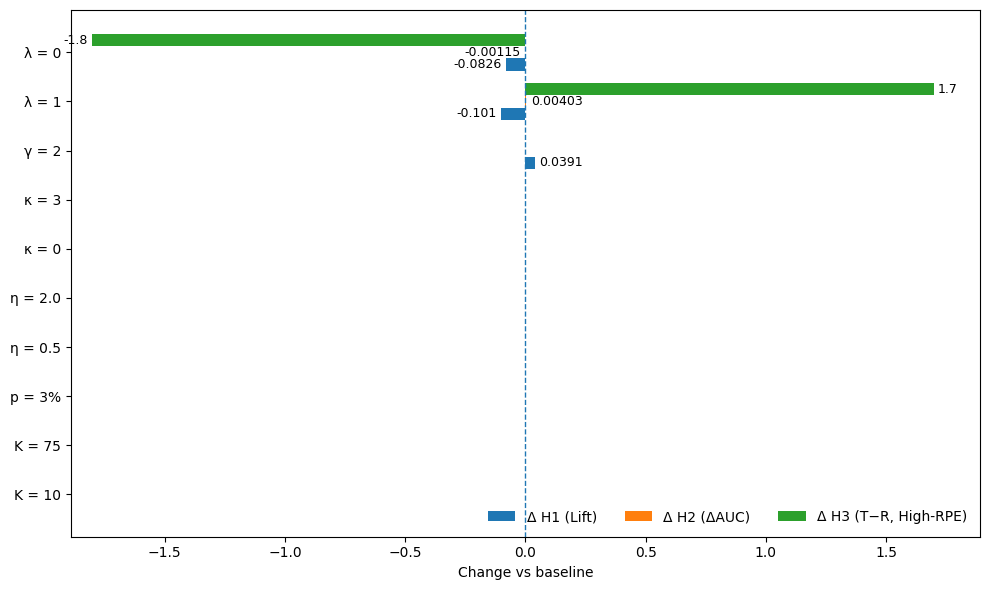

In [2]:
main()